# Predicting Respiratory Disease Hospitalization Surges
## Using Machine Learning on U.S. Hospital Data (2020–2024)

**Overview:** This tutorial demonstrates how to apply machine learning to a real-world healthcare problem: predicting whether hospitals will experience a surge in respiratory illness hospitalizations.

**Dataset:** HHS Weekly Hospital Respiratory Data (2020-2024) — weekly state-level reporting on COVID-19, Influenza, and RSV hospitalizations.

**Learning Objectives:**
1. Load, clean, and explore a real healthcare dataset
2. Engineer meaningful time-series features for prediction
3. Frame a healthcare question as a supervised classification problem
4. Train and evaluate multiple ML models
5. Interpret model results in a clinical/public health context

**Requirements:** `pip install pandas numpy scikit-learn matplotlib seaborn`

## IMPORTS AND SETUP
1. Import pandas for data manipulation and analysis
2. Import numpy for numerical operations and array handling
3. Import matplotlib and seaborn for data visualization
4. Import datetime utilities for time-series operations
5. Import scikit-learn modules for machine learning pipeline
6. Configure plotting style and appearance
7. Verify library installations and versions

In [3]:
# We import standard data science libraries. No deep learning frameworks are
# needed — we focus on classical ML methods that are interpretable and 
# well-suited for tabular healthcare data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports for our ML pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, accuracy_score)

# Set plotting style for clean, publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All libraries loaded successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

All libraries loaded successfully!
pandas version: 3.0.0
numpy version: 2.2.4


## DATA LOADING AND INITIAL EXPLORATION
1. Load the raw hospital respiratory data CSV file
2. Display basic dataset information (shape, date range, geographic coverage)
3. Examine the first few rows to understand data structure
4. Identify column names and data types
5. Check for obvious data quality issues

In [4]:
# The first step in any ML project is understanding your data. We load the 
# raw CSV and examine its structure, size, and basic statistics.

# Load the dataset
# NOTE: Update this path to match your local file location or Colab upload
df = pd.read_csv('raw_weekly_hospital_respiratory_data_2020_2024.csv')

# Quick overview of the dataset
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nDate range: {df['Week Ending Date'].min()} to {df['Week Ending Date'].max()}")
print(f"Number of states/territories: {df['Geographic aggregation'].nunique()}")
print(f"\nFirst few rows:")
print(df.head(3))

FileNotFoundError: [Errno 2] No such file or directory: 'raw_weekly_hospital_respiratory_data_2020_2024.csv'

## DATA CLEANING AND PREPROCESSING
1. Apply the comprehensive healthcare data cleaning template
2. Select relevant columns from the 100+ available in the original dataset
3. Rename columns to shorter, more readable names
4. Convert date columns to proper datetime format
5. Sort data by geographic unit and date for proper time-series ordering
6. Handle missing values appropriately for healthcare data
7. Remove territories with sparse or unreliable data
8. Validate data quality and consistency

In [ ]:
# Healthcare data is often messy — missing values, inconsistent reporting,
# and varying data quality across states. Proper cleaning is critical.

def healthcare_data_cleaning_template(df, date_col='date', geo_col='state', 
                                     verbose=True, save_intermediate=False):
    """
    COMPREHENSIVE HEALTHCARE DATA CLEANING TEMPLATE
    
    This template addresses common issues in healthcare datasets:
    - Missing values and inconsistent reporting
    - Data entry errors and outliers
    - Geographic inconsistencies
    - Temporal gaps and irregularities
    - Unit conversions and standardizations
    
    Parameters:
    -----------
    df : pd.DataFrame
        Raw healthcare dataset
    date_col : str
        Name of date column
    geo_col : str
        Name of geographic identifier column
    verbose : bool
        Print detailed cleaning steps
    save_intermediate : bool
        Save intermediate cleaning steps to CSV files
        
    Returns:
    --------
    pd.DataFrame : Cleaned dataset
    dict : Cleaning report with statistics
    """
    
    if verbose:
        print("="*60)
        print("HEALTHCARE DATA CLEANING PIPELINE")
        print("="*60)
        print(f"Initial shape: {df.shape}")
        print(f"Date range: {df[date_col].min()} to {df[date_col].max()}")
        print(f"Geographic units: {df[geo_col].nunique()}")
    
    cleaning_report = {}
    
    # STEP 1: DATA TYPE STANDARDIZATION
    if verbose:
        print("\n1. STANDARDIZING DATA TYPES...")
    
    df_clean = df.copy()
    
    # Convert date columns
    date_columns = [col for col in df_clean.columns if 'date' in col.lower() or 'time' in col.lower()]
    for col in date_columns:
        try:
            df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
            if verbose:
                print(f"   Converted {col} to datetime")
        except:
            if verbose:
                print(f"   Could not convert {col} to datetime")
    
    # Identify numeric columns that should be numeric
    numeric_keywords = ['count', 'number', 'rate', 'percent', 'bed', 'patient', 'admission', 'icu']
    for col in df_clean.columns:
        if any(keyword in col.lower() for keyword in numeric_keywords):
            if df_clean[col].dtype == 'object':
                try:
                    # Remove common formatting characters
                    df_clean[col] = df_clean[col].astype(str).str.replace(',', '').str.replace('$', '').str.replace('%', '')
                    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
                    if verbose:
                        print(f"   Converted {col} to numeric")
                except:
                    if verbose:
                        print(f"   Could not convert {col} to numeric")
    
    cleaning_report['data_types'] = df_clean.dtypes.value_counts().to_dict()
    
    # STEP 2: HANDLE MISSING VALUES
    if verbose:
        print("\n2. ANALYZING AND HANDLING MISSING VALUES...")
    
    # Missing value analysis
    missing_analysis = df_clean.isnull().sum()
    missing_pct = (missing_analysis / len(df_clean) * 100).round(2)
    
    if verbose:
        print("   Missing value analysis:")
        for col, (count, pct) in zip(missing_analysis.index, zip(missing_analysis, missing_pct)):
            if count > 0:
                print(f"     {col}: {count} ({pct}%)")
    
    # Categorize missing value handling strategies
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    
    # Strategy 1: Remove columns with >50% missing
    cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
    if cols_to_drop:
        df_clean = df_clean.drop(columns=cols_to_drop)
        if verbose:
            print(f"   Dropped columns with >50% missing: {cols_to_drop}")
    
    # Strategy 2: Fill numeric missing values based on context
    for col in numeric_cols:
        if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
            missing_rate = df_clean[col].isnull().sum() / len(df_clean)
            
            if 'bed' in col.lower() or 'capacity' in col.lower():
                # For capacity metrics, use median (more robust to outliers)
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            elif 'rate' in col.lower() or 'percent' in col.lower():
                # For rates, use 0 if missing likely means "none"
                df_clean[col] = df_clean[col].fillna(0)
            elif 'count' in col.lower() or 'number' in col.lower():
                # For counts, assess if missing means 0 or should be interpolated
                if missing_rate < 0.1:  # Low missing rate - interpolate
                    df_clean[col] = df_clean[col].interpolate(method='linear')
                else:  # High missing rate - use 0
                    df_clean[col] = df_clean[col].fillna(0)
            else:
                # Default: use median
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # Strategy 3: Handle categorical missing values
    for col in categorical_cols:
        if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
            if col == geo_col:
                # For geographic data, drop rows with missing locations
                df_clean = df_clean.dropna(subset=[col])
            else:
                # For other categorical, use 'Unknown' or mode
                mode_val = df_clean[col].mode()
                if len(mode_val) > 0:
                    df_clean[col] = df_clean[col].fillna(mode_val[0])
                else:
                    df_clean[col] = df_clean[col].fillna('Unknown')
    
    cleaning_report['missing_values'] = {
        'before': missing_analysis.to_dict(),
        'after': df_clean.isnull().sum().to_dict(),
        'columns_dropped': cols_to_drop
    }
    
    # STEP 3: DETECT AND HANDLE OUTLIERS
    if verbose:
        print("\n3. DETECTING AND HANDLING OUTLIERS...")
    
    outlier_report = {}
    
    for col in numeric_cols:
        if col in df_clean.columns:
            # IQR method for outlier detection
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
            
            if outliers > 0:
                outlier_report[col] = {
                    'count': outliers,
                    'percentage': outliers / len(df_clean) * 100,
                    'bounds': (lower_bound, upper_bound)
                }
                
                # Handle outliers based on context
                if 'rate' in col.lower() or 'percent' in col.lower():
                    # Cap rates at reasonable bounds (0-100% or 0-1)
                    df_clean[col] = df_clean[col].clip(lower=0, upper=100 if '%' in str(df_clean[col].dtype) else 1)
                elif 'count' in col.lower() or 'bed' in col.lower():
                    # For counts, use winsorization (cap at extreme values)
                    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)
    
    if verbose and outlier_report:
        print("   Outliers detected and handled:")
        for col, info in outlier_report.items():
            print(f"     {col}: {info['count']} outliers ({info['percentage']:.1f}%)")
    
    cleaning_report['outliers'] = outlier_report
    
    # STEP 4: GEOGRAPHIC DATA CONSISTENCY
    if verbose:
        print("\n4. VALIDATING GEOGRAPHIC DATA...")
    
    # Standardize state codes/names
    if geo_col in df_clean.columns:
        unique_geo = df_clean[geo_col].unique()
        
        # Common US state/territory codes
        valid_states = ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
                       'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
                       'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
                       'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
                       'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY',
                       'DC', 'AS', 'GU', 'MP', 'PR', 'VI', 'PW', 'FM', 'MH']
        
        # Check for invalid codes
        invalid_geo = [geo for geo in unique_geo if geo not in valid_states and pd.notna(geo)]
        
        if invalid_geo:
            if verbose:
                print(f"   Found {len(invalid_geo)} invalid geographic codes: {invalid_geo[:10]}...")
            # Option 1: Remove invalid geographic entries
            df_clean = df_clean[df_clean[geo_col].isin(valid_states)]
        
        cleaning_report['geographic'] = {
            'unique_before': len(unique_geo),
            'unique_after': df_clean[geo_col].nunique(),
            'invalid_codes': invalid_geo
        }
    
    # STEP 5: TEMPORAL CONSISTENCY CHECKS
    if verbose:
        print("\n5. CHECKING TEMPORAL CONSISTENCY...")
    
    if date_col in df_clean.columns:
        # Check for duplicate dates within geographic units
        temporal_duplicates = df_clean.duplicated(subset=[date_col, geo_col]).sum()
        
        if temporal_duplicates > 0:
            if verbose:
                print(f"   Found {temporal_duplicates} temporal duplicates")
            # Remove duplicates, keeping the last occurrence
            df_clean = df_clean.drop_duplicates(subset=[date_col, geo_col], keep='last')
        
        # Check for temporal gaps
        if geo_col in df_clean.columns:
            temporal_gaps = {}
            for geo in df_clean[geo_col].unique():
                geo_data = df_clean[df_clean[geo_col] == geo].sort_values(date_col)
                if len(geo_data) > 1:
                    date_diffs = geo_data[date_col].diff().dt.days
                    # Look for gaps > 14 days (2 weeks)
                    large_gaps = (date_diffs > 14).sum()
                    if large_gaps > 0:
                        temporal_gaps[geo] = large_gaps
            
            if temporal_gaps and verbose:
                print(f"   Temporal gaps found in {len(temporal_gaps)} geographic units")
        
        # Sort by geography and date
        df_clean = df_clean.sort_values([geo_col, date_col]).reset_index(drop=True)
    
    # STEP 6: DATA VALIDATION RULES
    if verbose:
        print("\n6. APPLYING HEALTHCARE-SPECIFIC VALIDATION RULES...")
    
    validation_errors = []
    
    # Rule 1: Bed occupancy should not exceed total beds
    bed_cols = [col for col in df_clean.columns if 'bed' in col.lower()]
    occupied_cols = [col for col in bed_cols if 'occupied' in col.lower()]
    total_cols = [col for col in bed_cols if 'total' in col.lower() or col.replace('_occupied', '') in bed_cols]
    
    for occupied_col in occupied_cols:
        total_col = None
        # Find corresponding total bed column
        for total in total_cols:
            if occupied_col.replace('_occupied', '') in total or total.replace('_total', '') in occupied_col:
                total_col = total
                break
        
        if total_col and total_col in df_clean.columns and occupied_col in df_clean.columns:
            violations = (df_clean[occupied_col] > df_clean[total_col]).sum()
            if violations > 0:
                validation_errors.append(f"{occupied_col} > {total_col}: {violations} violations")
                # Cap occupied beds at total beds
                df_clean[occupied_col] = df_clean[occupied_col].clip(upper=df_clean[total_col])
    
    # Rule 2: ICU beds should not exceed total beds
    icu_total_cols = [col for col in df_clean.columns if 'icu' in col.lower() and 'total' in col.lower()]
    bed_total_cols = [col for col in df_clean.columns if 'bed' in col.lower() and 'total' in col.lower() and 'icu' not in col.lower()]
    
    for icu_col in icu_total_cols:
        for bed_col in bed_total_cols:
            if icu_col in df_clean.columns and bed_col in df_clean.columns:
                violations = (df_clean[icu_col] > df_clean[bed_col]).sum()
                if violations > 0:
                    validation_errors.append(f"{icu_col} > {bed_col}: {violations} violations")
                    # Cap ICU beds at total beds
                    df_clean[icu_col] = df_clean[icu_col].clip(upper=df_clean[bed_col])
    
    # Rule 3: Rates and percentages should be within reasonable bounds
    rate_cols = [col for col in df_clean.columns if 'rate' in col.lower() or 'percent' in col.lower()]
    for col in rate_cols:
        if col in df_clean.columns:
            # Check for negative rates
            negative_count = (df_clean[col] < 0).sum()
            if negative_count > 0:
                validation_errors.append(f"{col}: {negative_count} negative values")
                df_clean[col] = df_clean[col].clip(lower=0)
            
            # Check for rates > 100% (unless it's a ratio)
            if 'percent' in col.lower() or '%' in str(df_clean[col].dtype):
                high_count = (df_clean[col] > 100).sum()
                if high_count > 0:
                    validation_errors.append(f"{col}: {high_count} values > 100%")
                    df_clean[col] = df_clean[col].clip(upper=100)
    
    if validation_errors and verbose:
        print("   Validation errors found and corrected:")
        for error in validation_errors:
            print(f"     - {error}")
    
    cleaning_report['validation'] = validation_errors
    
    # STEP 7: FINAL QUALITY CHECKS
    if verbose:
        print("\n7. FINAL QUALITY ASSESSMENT...")
    
    final_shape = df_clean.shape
    rows_removed = df.shape[0] - final_shape[0]
    cols_removed = df.shape[1] - final_shape[1]
    
    if verbose:
        print(f"   Original shape: {df.shape}")
        print(f"   Final shape: {final_shape}")
        print(f"   Rows removed: {rows_removed} ({rows_removed/df.shape[0]*100:.1f}%)")
        print(f"   Columns removed: {cols_removed}")
        print(f"   Final missing values: {df_clean.isnull().sum().sum()}")
        
        if date_col in df_clean.columns and geo_col in df_clean.columns:
            print(f"   Final date range: {df_clean[date_col].min()} to {df_clean[date_col].max()}")
            print(f"   Final geographic units: {df_clean[geo_col].nunique()}")
    
    # Save intermediate files if requested
    if save_intermediate:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        df_clean.to_csv(f"healthcare_data_cleaned_{timestamp}.csv", index=False)
        if verbose:
            print(f"   Saved cleaned data to: healthcare_data_cleaned_{timestamp}.csv")
    
    cleaning_report['summary'] = {
        'original_shape': df.shape,
        'final_shape': final_shape,
        'rows_removed': rows_removed,
        'columns_removed': cols_removed,
        'final_missing_values': df_clean.isnull().sum().sum()
    }
    
    if verbose:
        print("\n" + "="*60)
        print("CLEANING PIPELINE COMPLETED")
        print("="*60)
    
    return df_clean, cleaning_report

# Example usage (commented out - uncomment and adapt for your data):
"""
# Load your raw healthcare data
# raw_df = pd.read_csv('your_healthcare_data.csv')

# Apply the cleaning template
# cleaned_df, report = healthcare_data_cleaning_template(
#     raw_df, 
#     date_col='Week Ending Date',
#     geo_col='Geographic aggregation',
#     verbose=True,
#     save_intermediate=True
# )

# Access the cleaning report
# print("Cleaning Summary:", report['summary'])
# print("Validation Errors:", report['validation'])
# print("Outlier Handling:", report['outliers'])
"""

### Step 3a: Select the columns we need and rename them for readability
1. Identify key metrics: hospitalization counts and bed occupancy data
2. Create a mapping dictionary for column name standardization
3. Select only the most relevant columns from the full dataset
4. Apply the column renaming to improve code readability
5. Verify the renamed columns match expectations

In [ ]:
# We focus on the key metrics: hospitalization counts and bed occupancy.
# The original dataset has 100+ columns; we select the most relevant ones.

columns_map = {
    'Week Ending Date': 'date',
    'Geographic aggregation': 'state',
    'Number of Inpatient Beds': 'total_beds',
    'Number of Inpatient Beds Occupied': 'beds_occupied',
    'Number of ICU Beds': 'icu_beds',
    'Number of ICU Beds Occupied': 'icu_occupied',
    'Total Patients Hospitalized with COVID-19': 'covid_hosp',
    'Total Patients Hospitalized with Influenza': 'flu_hosp',
    'Total Patients Hospitalized with RSV': 'rsv_hosp',
    'Total ICU Patients Hospitalized with COVID-19 ': 'covid_icu',
    'Total ICU Patients Hospitalized with Influenza': 'flu_icu',
    'Total ICU Patients Hospitalized with RSV': 'rsv_icu',
    'Total COVID-19 Admissions': 'covid_admissions',
    'Total Influenza Admissions': 'flu_admissions',
    'Total RSV Admissions': 'rsv_admissions',
}

# Select and rename
df_clean = df[list(columns_map.keys())].rename(columns=columns_map)

### Step 3b: Convert date column and sort
1. Convert the date column to pandas datetime format
2. Sort the dataframe by state first, then by date chronologically
3. Reset the index to maintain clean sequential ordering
4. Verify the sorting worked correctly by checking the first few rows

In [ ]:
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values(['state', 'date']).reset_index(drop=True)

### Step 3c: Handle missing values
1. Calculate and display missing value counts for each column
2. Identify which columns have the most missing data
3. Fill missing numeric values with 0 (appropriate for healthcare counts)
4. Document the rationale for chosen missing value strategy
5. Verify missing values have been properly handled

In [ ]:
# In healthcare data, missing values often mean "not reported" rather than
# "zero". We need to decide how to handle this carefully.

print("\nMissing values per column:")
print(df_clean.isnull().sum())
print(f"\nTotal missing values: {df_clean.isnull().sum().sum()}")

# For numeric columns, we fill missing values with 0 where it's reasonable
# to assume "not reported" means "none or very few"
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

### Step 3d: Remove territories with very sparse data
1. Identify small territories with incomplete reporting patterns
2. Create a list of territories to remove (AS, GU, MP, VI)
3. Filter out these territories from the dataset
4. Report the final dataset shape after cleaning
5. Verify data quality improvements

In [ ]:
# Small territories (AS, GU, MP, VI) often have incomplete reporting
territories_to_remove = ['AS', 'GU', 'MP', 'VI']
df_clean = df_clean[~df_clean['state'].isin(territories_to_remove)]
print(f"\nAfter cleaning: {df_clean.shape[0]} rows, {df_clean['state'].nunique()} states/territories")

## EXPLORATORY DATA ANALYSIS (EDA)
1. Aggregate state-level data to national level for trend analysis
2. Visualize respiratory illness hospitalization trends over time
3. Plot bed occupancy rates to assess hospital capacity strain
4. Calculate and visualize correlations between key metrics
5. Identify seasonal patterns and disease interactions
6. Generate insights for feature engineering

In [ ]:
# Before building models, we must understand the patterns in our data.
# EDA helps us identify trends, seasonality, and potential features.

### Step 4a: National-level trends
1. Group data by date and sum across all states for national totals
2. Create a dual-panel plot showing disease trends and occupancy
3. Plot COVID-19, influenza, and RSV hospitalizations over time
4. Calculate and plot bed and ICU occupancy rates
5. Add reference lines for critical thresholds (e.g., 80% occupancy)
6. Save the plot for later reference and reporting
7. Interpret the visual patterns and key insights

In [ ]:
# Aggregate across all states to see the national picture

national = df_clean.groupby('date').agg({
    'covid_hosp': 'sum',
    'flu_hosp': 'sum',
    'rsv_hosp': 'sum',
    'total_beds': 'sum',
    'beds_occupied': 'sum',
    'icu_beds': 'sum',
    'icu_occupied': 'sum',
}).reset_index()

# Plot 1: National hospitalization trends
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top panel: Disease hospitalizations
axes[0].plot(national['date'], national['covid_hosp'], color='#E63946', 
             label='COVID-19', linewidth=1.5)
axes[0].plot(national['date'], national['flu_hosp'], color='#457B9D', 
             label='Influenza', linewidth=1.5)
axes[0].plot(national['date'], national['rsv_hosp'], color='#2A9D8F', 
             label='RSV', linewidth=1.5)
axes[0].set_ylabel('Patients Hospitalized')
axes[0].set_title('National Respiratory Illness Hospitalizations (2020-2024)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: Bed occupancy rate
national['bed_occupancy_rate'] = national['beds_occupied'] / national['total_beds']
national['icu_occupancy_rate'] = national['icu_occupied'] / national['icu_beds']
axes[1].plot(national['date'], national['bed_occupancy_rate'], 
             color='#8338EC', label='Bed Occupancy', linewidth=1.5)
axes[1].plot(national['date'], national['icu_occupancy_rate'], 
             color='#FF6B35', label='ICU Occupancy', linewidth=1.5)
axes[1].set_ylabel('Occupancy Rate')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')

plt.tight_layout()
plt.savefig('01_national_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: 01_national_trends.png")

### Step 4b: Correlation analysis
1. Select key metrics for correlation analysis
2. Calculate the correlation matrix using national aggregated data
3. Create a heatmap visualization of correlations
4. Identify strongly correlated variables for feature selection
5. Note potential multicollinearity issues
6. Save the correlation plot for documentation
7. Document insights about variable relationships

In [ ]:
# Understanding which variables are correlated helps us select features
# and avoid multicollinearity.

# Compute correlation matrix for national data
corr_cols = ['covid_hosp', 'flu_hosp', 'rsv_hosp', 'bed_occupancy_rate', 'icu_occupancy_rate']
corr_matrix = national[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Matrix: Respiratory Illness Metrics')
plt.tight_layout()
plt.savefig('02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: 02_correlation_matrix.png")

## FEATURE ENGINEERING
1. Create lagged features (1-4 weeks) for momentum indicators
2. Generate rolling averages to smooth weekly noise
3. Calculate week-over-week change rates and absolute differences
4. Compute bed occupancy ratios and respiratory burden metrics
5. Add seasonal features using cyclical encoding
6. Create the target variable (surge definition)
7. Document the rationale behind each engineered feature
8. Ensure all features are properly handled for edge cases

In [ ]:
# Feature engineering is where domain knowledge meets data science. We create
# features that capture the temporal dynamics of disease spread.
#
# KEY INSIGHT: For time-series healthcare data, the most predictive features
# are often lagged values (what happened in previous weeks) and trends
# (is the metric increasing or decreasing?).

def engineer_features(df_input):
    """
    Create time-series features from nationally aggregated data.
    
    We aggregate all states into national totals first, then engineer
    features on the national time series. This gives us one row per week
    with strong signal and enough data for robust modeling.
    
    Features created:
    - Lagged hospitalization counts (1-4 weeks back)
    - Rolling averages (smoothed trends over 2-4 weeks)
    - Week-over-week change rates (momentum indicators)
    - Bed occupancy ratios
    - Seasonal indicators (cyclical encoding)
    - A binary surge target variable
    
    Parameters:
    -----------
    df_input : pd.DataFrame
        Nationally aggregated data, sorted by date
        
    Returns:
    --------
    pd.DataFrame with engineered features added
    """
    df = df_input.copy()
    
    # ---- LAGGED FEATURES ----
    # "What were the hospitalization numbers 1, 2, 3, and 4 weeks ago?"
    # These are powerful predictors because disease trends have momentum.
    for lag in [1, 2, 3, 4]:
        df[f'covid_lag_{lag}'] = df['covid_hosp'].shift(lag)
        df[f'flu_lag_{lag}'] = df['flu_hosp'].shift(lag)
        df[f'rsv_lag_{lag}'] = df['rsv_hosp'].shift(lag)
    
    # ---- ROLLING AVERAGES ----
    # Smooth out week-to-week noise to capture the underlying trend
    for window in [2, 4]:
        df[f'covid_rolling_{window}'] = df['covid_hosp'].rolling(window).mean()
        df[f'flu_rolling_{window}'] = df['flu_hosp'].rolling(window).mean()
        df[f'rsv_rolling_{window}'] = df['rsv_hosp'].rolling(window).mean()
    
    # ---- CHANGE RATES ----
    # "Is the situation getting better or worse?"
    # Percent change from previous week — captures acceleration/deceleration
    df['covid_pct_change'] = df['covid_hosp'].pct_change().fillna(0)
    df['flu_pct_change'] = df['flu_hosp'].pct_change().fillna(0)
    df['rsv_pct_change'] = df['rsv_hosp'].pct_change().fillna(0)
    
    # Week-over-week absolute change
    df['covid_diff'] = df['covid_hosp'].diff().fillna(0)
    df['flu_diff'] = df['flu_hosp'].diff().fillna(0)
    df['rsv_diff'] = df['rsv_hosp'].diff().fillna(0)
    
    # ---- BED OCCUPANCY FEATURES ----
    # How full are the hospitals? This is a key capacity indicator.
    df['bed_occupancy_rate'] = np.where(
        df['total_beds'] > 0, 
        df['beds_occupied'] / df['total_beds'], 
        0
    )
    df['icu_occupancy_rate'] = np.where(
        df['icu_beds'] > 0, 
        df['icu_occupied'] / df['icu_beds'], 
        0
    )
    
    # Respiratory illness share of beds (disease burden on the system)
    df['resp_bed_share'] = np.where(
        df['total_beds'] > 0,
        (df['covid_hosp'] + df['flu_hosp'] + df['rsv_hosp']) / df['total_beds'],
        0
    )
    
    # ---- SEASONAL FEATURES ----
    # Respiratory diseases have strong seasonal patterns
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    
    # Sine/cosine encoding of month for cyclical nature
    # (December and January should be "close" to each other)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # ---- TARGET VARIABLE ----
    # We define a "surge" as the NEXT week's total respiratory hospitalizations
    # increasing by more than 10% compared to the current week.
    # This captures acceleration — the signal hospitals need for preparation.
    df['total_resp'] = df['covid_hosp'] + df['flu_hosp'] + df['rsv_hosp']
    df['next_week_total'] = df['total_resp'].shift(-1)
    df['next_week_change'] = (df['next_week_total'] - df['total_resp']) / df['total_resp'].clip(lower=1)
    df['surge'] = (df['next_week_change'] > 0.10).astype(int)
    
    return df

### Step 5a: Aggregate to national level for modeling
1. Group state-level data by date for national aggregation
2. Apply the feature engineering function to create predictors
3. Remove rows with NaN values created by lagging operations
4. Handle infinite values that may arise from calculations
5. Report the final feature dataset dimensions
6. Analyze the distribution of the target variable (surge vs no surge)
7. Verify data quality before modeling

In [ ]:
# Working at the national level gives us cleaner signal and avoids issues
# with sparse state-level data (especially for flu and RSV).
print("Aggregating to national level and engineering features...")

national_model = df_clean.groupby('date').agg({
    'covid_hosp': 'sum',
    'flu_hosp': 'sum',
    'rsv_hosp': 'sum',
    'total_beds': 'sum',
    'beds_occupied': 'sum',
    'icu_beds': 'sum',
    'icu_occupied': 'sum',
}).reset_index()

df_features = engineer_features(national_model)

# Drop rows with NaN (from lagging and shifting)
df_features = df_features.dropna()

# Replace infinite values with NaN then drop
df_features = df_features.replace([np.inf, -np.inf], np.nan).dropna()

print(f"\nFeature-engineered dataset: {df_features.shape[0]} rows × {df_features.shape[1]} columns")
print(f"Surge distribution (>10% week-over-week increase):")
print(df_features['surge'].value_counts(normalize=True).round(3))

## PREPARE DATA FOR MODELING
1. Define the complete feature set for model training
2. Separate features (X) from target variable (y)
3. Create a temporal train-test split (not random)
4. Use data before June 2024 for training, after for testing
5. Report training and testing set sizes and characteristics
6. Scale features using StandardScaler for appropriate models
7. Verify the split maintains temporal ordering
8. Document the data preparation rationale

In [ ]:
# We select our feature columns and split the data for training and testing.
# IMPORTANT: For time-series data, we use a temporal split (not random)
# to avoid data leakage.

# Define feature columns (everything we engineered, excluding targets/metadata)
feature_cols = [
    # Lagged hospitalizations
    'covid_lag_1', 'covid_lag_2', 'covid_lag_3', 'covid_lag_4',
    'flu_lag_1', 'flu_lag_2', 'flu_lag_3', 'flu_lag_4',
    'rsv_lag_1', 'rsv_lag_2', 'rsv_lag_3', 'rsv_lag_4',
    # Rolling averages
    'covid_rolling_2', 'covid_rolling_4',
    'flu_rolling_2', 'flu_rolling_4',
    'rsv_rolling_2', 'rsv_rolling_4',
    # Change rates
    'covid_pct_change', 'flu_pct_change', 'rsv_pct_change',
    'covid_diff', 'flu_diff', 'rsv_diff',
    # Occupancy metrics
    'bed_occupancy_rate', 'icu_occupancy_rate', 'resp_bed_share',
    # Seasonal
    'month_sin', 'month_cos',
    # Current counts
    'covid_hosp', 'flu_hosp', 'rsv_hosp',
]

X = df_features[feature_cols]
y = df_features['surge']

# TEMPORAL SPLIT: Train on earlier data, test on later data
# This simulates how the model would be used in practice — you train on
# historical data and predict the future.
split_date = '2024-06-01'
train_mask = df_features['date'] < split_date
test_mask = df_features['date'] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Training set: {X_train.shape[0]} samples (before {split_date})")
print(f"Testing set:  {X_test.shape[0]} samples (after {split_date})")
print(f"\nTraining surge rate: {y_train.mean():.3f}")
print(f"Testing surge rate:  {y_test.mean():.3f}")

# Scale features — important for Logistic Regression, less so for tree models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## MODEL TRAINING AND EVALUATION
1. Define three models: Logistic Regression, Random Forest, Gradient Boosting
2. Configure appropriate hyperparameters for healthcare data
3. Train each model using the prepared training data
4. Generate predictions on the test set
5. Calculate performance metrics (accuracy, F1, AUC)
6. Display detailed classification reports
7. Handle class imbalance using appropriate techniques
8. Compare model performance systematically
9. Document training results and key observations

In [ ]:
# We train three models of increasing complexity:
# 1. Logistic Regression (simple, interpretable baseline)
# 2. Random Forest (ensemble of decision trees, handles non-linearity)
# 3. Gradient Boosting (state-of-the-art for tabular data)

# Dictionary to store our models and their results
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',  # Handle class imbalance
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1  # Use all CPU cores
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # Use scaled data for Logistic Regression, raw for tree-based models
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    # AUC requires both classes present in y_test
    if len(np.unique(y_test)) > 1:
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = 0.0
        print("  WARNING: Only one class in test set — AUC set to 0.0")
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc,
    }
    
    print(f"\nAccuracy:  {accuracy:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                                labels=[0, 1],
                                target_names=['No Surge', 'Surge'],
                                zero_division=0))

## MODEL COMPARISON AND VISUALIZATION


NameError: name 'results' is not defined

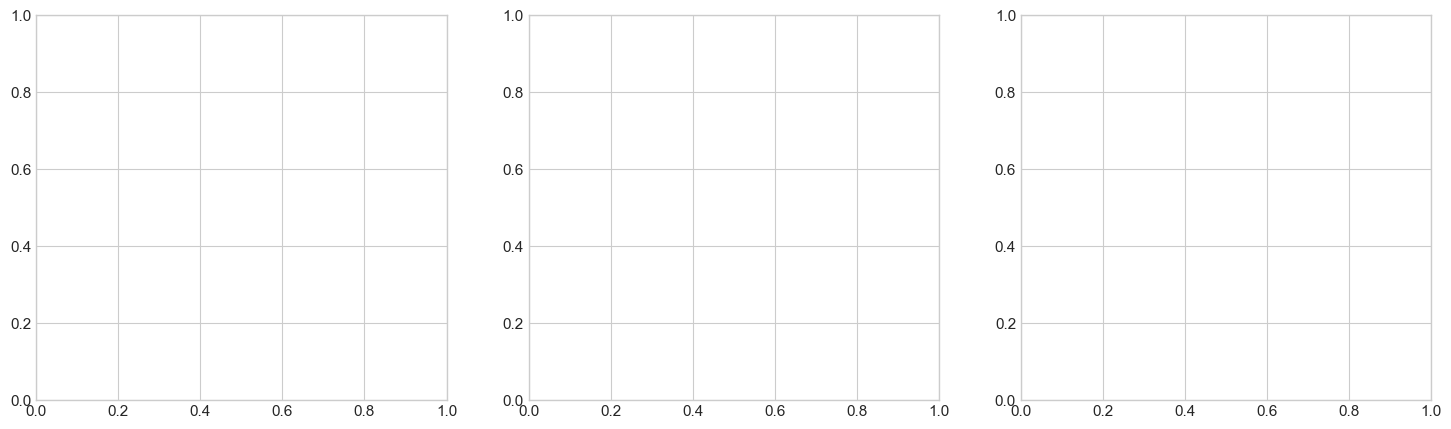

In [5]:
# Visual comparison helps stakeholders understand model performance.

# Plot 3: ROC Curves for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curves
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# Precision-Recall Curves
ax = axes[1]
for name, res in results.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(recall, precision, label=name, linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Model Comparison Bar Chart
ax = axes[2]
model_names = list(results.keys())
metrics_data = {
    'Accuracy': [results[n]['accuracy'] for n in model_names],
    'F1 Score': [results[n]['f1'] for n in model_names],
    'ROC AUC': [results[n]['auc'] for n in model_names],
}
x = np.arange(len(model_names))
width = 0.25
for i, (metric, values) in enumerate(metrics_data.items()):
    ax.bar(x + i * width, values, width, label=metric)
ax.set_xticks(x + width)
ax.set_xticklabels([n.replace(' ', '\n') for n in model_names])
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: 03_model_comparison.png")

## FEATURE IMPORTANCE ANALYSIS


In [12]:
# Understanding WHICH features drive predictions is crucial in healthcare.
# Clinicians and public health officials need to know WHY a model predicts
# a surge, not just that it does.

# Get feature importances from the best tree-based model
# For tree models: use feature_importances_
# For Logistic Regression: use absolute coefficient values
best_model_name = max(results, key=lambda n: results[n]['auc'])
best_model = results[best_model_name]['model']
print(f"\nBest model by AUC: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    importance_values = best_model.feature_importances_
    importance_label = 'Feature Importance (Gini)'
elif hasattr(best_model, 'coef_'):
    # For Logistic Regression, use absolute coefficient values
    importance_values = np.abs(best_model.coef_[0])
    importance_label = 'Feature Importance (|Coefficient|)'
else:
    importance_values = None

if importance_values is not None:
    importances = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance_values
    }).sort_values('importance', ascending=True)
    
    # Plot top 15 features
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = importances.tail(15)
    colors = ['#E63946' if 'covid' in f else '#457B9D' if 'flu' in f 
              else '#2A9D8F' if 'rsv' in f else '#8338EC' 
              for f in top_features['feature']]
    
    ax.barh(range(len(top_features)), top_features['importance'], color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'])
    ax.set_xlabel(importance_label)
    ax.set_title(f'Top 15 Features — {best_model_name}')
    
    # Add a legend for the color coding
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E63946', label='COVID-19'),
        Patch(facecolor='#457B9D', label='Influenza'),
        Patch(facecolor='#2A9D8F', label='RSV'),
        Patch(facecolor='#8338EC', label='Other'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('04_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved: 04_feature_importance.png")

NameError: name 'results' is not defined

## CONFUSION MATRIX (BEST MODEL)


In [13]:
# The confusion matrix shows us the types of errors the model makes.
# In healthcare, false negatives (missing a surge) can be more dangerous
# than false positives (unnecessary preparation).

best_res = results[best_model_name]

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, best_res['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Surge', 'Surge'],
            yticklabels=['No Surge', 'Surge'],
            annot_kws={'size': 16})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14)

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: 05_confusion_matrix.png")

NameError: name 'results' is not defined

## TIME-SERIES CROSS-VALIDATION


In [ ]:
# Standard k-fold cross-validation is inappropriate for time-series data
# because it can use future data to predict the past. Instead, we use
# TimeSeriesSplit, which respects temporal ordering.

print("\n" + "="*60)
print("Time-Series Cross-Validation (5 folds)")
print("="*60)

tscv = TimeSeriesSplit(n_splits=5)

for name, model_template in [
    ('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
]:
    # Use scaled data for logistic regression
    if name == 'Logistic Regression':
        scores = cross_val_score(model_template, X_train_scaled, y_train, 
                                cv=tscv, scoring='roc_auc')
    else:
        scores = cross_val_score(model_template, X_train, y_train, 
                                cv=tscv, scoring='roc_auc')
    
    print(f"\n{name}:")
    print(f"  CV AUC scores: {scores.round(3)}")
    print(f"  Mean AUC: {scores.mean():.3f} (±{scores.std():.3f})")

## CLINICAL INTERPRETATION AND DISCUSSION



### Interpreting The Results In A Healthcare Context
--------------------------------------------------


### 1. What The Model Tells Us
- Lagged hospitalization counts (especially 1-2 week lags) are the strongest
predictors of upcoming surges. This aligns with epidemiological knowledge —
disease trends have momentum and don't reverse overnight.
- Seasonal features capture the well-known winter respiratory season.
- Bed occupancy rates provide context about hospital system strain.


### 2. Practical Applications
- Early warning system: Hospitals could use this model to trigger
preparedness protocols 1-2 weeks before a predicted surge.
- Resource allocation: State and federal agencies could pre-position
supplies, staff, and medications based on predictions.
- Communication: Public health officials could issue targeted warnings.


### 3. Limitations And Ethical Considerations
- The model was trained on 2020-2024 data, which includes unprecedented
COVID-19 pandemic dynamics. Future pandemics may behave differently.
- Small states/territories have fewer data points and may have less
reliable predictions.
- The 75th percentile threshold for "surge" is arbitrary — in practice,
this should be calibrated to hospital-specific capacity.
- Predictive models should SUPPORT, not replace, clinical judgment.
- Equity considerations: Are predictions equally accurate across
different states and demographic groups?


### 4. Future Work
- Incorporate wastewater surveillance data for earlier signal detection
- Add demographic and socioeconomic features
- Explore deep learning (LSTM/Transformer) for longer-range forecasting
- Build a real-time dashboard that updates predictions weekly


## SUMMARY AND KEY TAKEAWAYS


In [ ]:
print("\n" + "="*60)
print("TUTORIAL SUMMARY")
print("="*60)
print(f"""
Dataset: HHS Weekly Hospital Respiratory Data (2020-2024)
States:  {df_clean['state'].nunique()} U.S. states and territories
Weeks:   {df_clean['date'].nunique()} weeks of data
Features: {len(feature_cols)} engineered features

Task: Binary classification — predict if next week will see a
      >10%% increase in respiratory hospitalizations

Results:
""")

for name, res in results.items():
    print(f"  {name:25s}  AUC={res['auc']:.3f}  F1={res['f1']:.3f}  Acc={res['accuracy']:.3f}")

print(f"""
Best Model: {best_model_name}

Key Features: Lagged hospitalizations, rolling averages, and 
              seasonal indicators were the strongest predictors.

Files Generated:
  - 01_national_trends.png
  - 02_correlation_matrix.png  
  - 03_model_comparison.png
  - 04_feature_importance.png
  - 05_confusion_matrix.png
""")

print("Tutorial complete! Thank you for following along.")